<a href="https://colab.research.google.com/github/evelynsaez/analisis_suicidios_antioquia/blob/data_zharita/Proyecto_Evelyn_Isamar_Yurany.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd #Se importa libreria de pandas
import numpy as np #Se importa libreria de numpy
import matplotlib.pyplot as plt #Se importa libreria de matplotlib
import seaborn as sns #Se importa libreria de seaborn

#Se importa el archivo desde github
url = ('https://github.com/evelynsaez/analisis_suicidios_antioquia/raw/refs/heads/data_zharita/Cantidad_anual_de_suicidios_reportados_en_el_Departamento_de_Antioquia_desde_2005_20251127.csv')
df = pd.read_csv(url) #Se lee el archivo en formato csv con pandas
df.head(5) #Se puede observar los primeros registros de la hoja de calculo


#https://www.canva.com/design/DAG7Dmyizq4/v7tl6Un7OUyOwFx8v-OtdQ/edit?utm_content=DAG7Dmyizq4&utm_campaign=designshare&utm_medium=link2&utm_source=sharebutton

,NombreMunicipio,CodigoMunicipio,Ubicación,NombreRegion,CodigoRegion,Anio,CausaMortalidad,TipoPoblacionObjetivo,NumeroPoblacionObjetivo,NumeroCasos
0,Abejorral,5002,POINT (-75.427045 5.79145),ORIENTE,7,2005,Suicidios,Poblacion total,"20,249",2
1,Abriaquí,5004,POINT (-76.064563 6.63197),OCCIDENTE,6,2005,Suicidios,Poblacion total,"2,690",0
2,Alejandría,5021,POINT (-75.141258 6.376923),ORIENTE,7,2005,Suicidios,Poblacion total,"3,816",0
3,Amagá,5030,POINT (-75.703216 6.04063),SUROESTE,8,2005,Suicidios,Poblacion total,"27,155",0
4,Amalfi,5031,POINT (-75.075028 6.907385),NORDESTE,4,2005,Suicidios,Poblacion total,"20,525",2


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   NombreMunicipio          2500 non-null   object
 1   CodigoMunicipio          2500 non-null   int64 
 2   Ubicación                2500 non-null   object
 3   NombreRegion             2500 non-null   object
 4   CodigoRegion             2500 non-null   int64 
 5   Anio                     2500 non-null   int64 
 6   CausaMortalidad          2500 non-null   object
 7   TipoPoblacionObjetivo    2500 non-null   object
 8   NumeroPoblacionObjetivo  2500 non-null   object
 9   NumeroCasos              2500 non-null   int64 
dtypes: int64(4), object(6)
memory usage: 195.4+ KB


In [13]:
import pandas as pd #Se importa libreria de pandas
import numpy as np #Se importa libreria de numpy
import matplotlib.pyplot as plt #Se importa libreria de matplotlib
import seaborn as sns #Se importa libreria de seaborn

#Se importa el archivo desde github
url = ('https://github.com/evelynsaez/analisis_suicidios_antioquia/raw/refs/heads/data_zharita/Cantidad_anual_de_suicidios_reportados_en_el_Departamento_de_Antioquia_desde_2005_20251127.csv')
df = pd.read_csv(url) #Se lee el archivo en formato csv con pandas
#Se reemplaza las comas por espacio y float por int
df['NumeroPoblacionObjetivo'] = df['NumeroPoblacionObjetivo'].str.replace(',', '').astype(float).astype(int)
df.head(5) #Se puede observar los primeros registros de la hoja de calculo


,NombreMunicipio,CodigoMunicipio,Ubicación,NombreRegion,CodigoRegion,Anio,CausaMortalidad,TipoPoblacionObjetivo,NumeroPoblacionObjetivo,NumeroCasos
0,Abejorral,5002,POINT (-75.427045 5.79145),ORIENTE,7,2005,Suicidios,Poblacion total,20249,2
1,Abriaquí,5004,POINT (-76.064563 6.63197),OCCIDENTE,6,2005,Suicidios,Poblacion total,2690,0
2,Alejandría,5021,POINT (-75.141258 6.376923),ORIENTE,7,2005,Suicidios,Poblacion total,3816,0
3,Amagá,5030,POINT (-75.703216 6.04063),SUROESTE,8,2005,Suicidios,Poblacion total,27155,0
4,Amalfi,5031,POINT (-75.075028 6.907385),NORDESTE,4,2005,Suicidios,Poblacion total,20525,2


In [14]:
import re
#Se eliminan las columnas CausaMortalida, CodigoRegion, CodigoMunicipio y TipoPoblacionObjetivo
df_sincolumnas = df.drop(['CausaMortalidad', 'TipoPoblacionObjetivo', 'CodigoRegion', 'CodigoMunicipio'], axis=1)
#Se cambia el nombre de las columnas
df_nuevo_nombre = df_sincolumnas.rename(columns={'NombreMunicipio': 'Municipio', 'NombreRegion': 'Region','NumeroPoblacionObjetivo': 'Poblacion','NumeroCasos': 'Casos'})
# Extraer lat/lon del formato POINT
def extract_coords(wkt_point):
    #Encuentra y devuelve una lista de todas las coincidencias
    match = re.findall(r"[-+]?\d*\.\d+|\d+", wkt_point)
    if len(match) == 2:
        lon = float(match[0])
        lat = float(match[1])
        return lat, lon
    return None, None

df_nuevo_nombre["Lat"], df_nuevo_nombre["Lon"] = zip(*df_nuevo_nombre["Ubicación"].apply(extract_coords))

df_nuevo_nombre.head(5)


,Municipio,Ubicación,Region,Anio,Poblacion,Casos,Lat,Lon
0,Abejorral,POINT (-75.427045 5.79145),ORIENTE,2005,20249,2,5.791450,-75.427045
1,Abriaquí,POINT (-76.064563 6.63197),OCCIDENTE,2005,2690,0,6.631970,-76.064563
2,Alejandría,POINT (-75.141258 6.376923),ORIENTE,2005,3816,0,6.376923,-75.141258
3,Amagá,POINT (-75.703216 6.04063),SUROESTE,2005,27155,0,6.040630,-75.703216
4,Amalfi,POINT (-75.075028 6.907385),NORDESTE,2005,20525,2,6.907385,-75.075028


In [15]:
df_nuevo_nombre.shape #Se confirman cuantas columnas y filas tiene el dataframe al quitar las columnas no relevantes

(2500, 8)

In [16]:
df_nuevo_nombre.info () #Se observa que no hay datos nulos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Municipio  2500 non-null   object 
 1   Ubicación  2500 non-null   object 
 2   Region     2500 non-null   object 
 3   Anio       2500 non-null   int64  
 4   Poblacion  2500 non-null   int64  
 5   Casos      2500 non-null   int64  
 6   Lat        2500 non-null   float64
 7   Lon        2500 non-null   float64
dtypes: float64(2), int64(3), object(3)
memory usage: 156.4+ KB


In [17]:
# Calcular estadísticas básicas (media, mediana, desviación estándar)
media = df_nuevo_nombre['Casos'].mean()
mediana = df_nuevo_nombre['Casos'].median()
desviacion_estandar = df_nuevo_nombre['Casos'].std()
suma_columna_casos = df["NumeroCasos"].sum() #Suma los casos de suicidio en 20 años

print (f'''
El promedio del # de suicidios en Antioquia en los ultimos 20 años es: {media} casos
La mediana del # de suicidios en Antioquia en los ultimos 20 años es de: {mediana} casos
La desviación estandar del # de suicidios en Antioquia en los ultimos 20 años es de: {desviacion_estandar} casos
El total de suicidios en Antioquia en los últimos 20 años fue de: {suma_columna_casos} casos

''')


El promedio del # de suicidios en Antioquia en los ultimos 20 años es: 3.1664 casos
La mediana del # de suicidios en Antioquia en los ultimos 20 años es de: 1.0 casos
La desviación estandar del # de suicidios en Antioquia en los ultimos 20 años es de: 15.003438016032302 casos
El total de suicidios en Antioquia en los últimos 20 años fue de: 7916 casos




In [18]:
#Agrupa los casos por region para mostrar cuantos casos hubo en cada region
df_nuevo_nombre = df_nuevo_nombre[(df_nuevo_nombre['Anio'] >= 2005) & (df_nuevo_nombre['Anio'] <= 2024)]
suma_casos_region = df_nuevo_nombre.groupby('Region')['Casos'].sum().reset_index()

suma_casos_region

,Region,Casos
0,BAJO CAUCA,206
1,MAGDALENA MEDIO,126
2,NORDESTE,267
3,NORTE,372
4,OCCIDENTE,257
5,ORIENTE,948
6,SUROESTE,573
7,URABA,421
8,VALLE DE ABURRA,4746


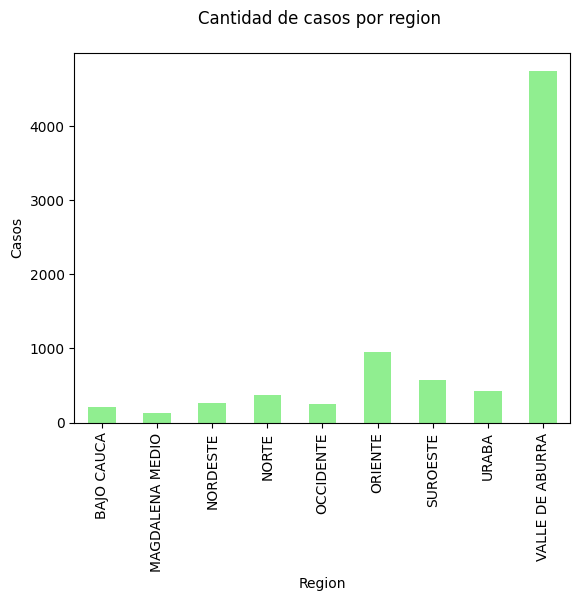

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Crear el gráfico directamente desde el DataFrame
suma_casos_region.plot(kind='bar', x='Region',
                       y='Casos', legend=False, color='lightgreen')
plt.title('Cantidad de casos por region \n')
plt.ylabel('Casos')
plt.show()

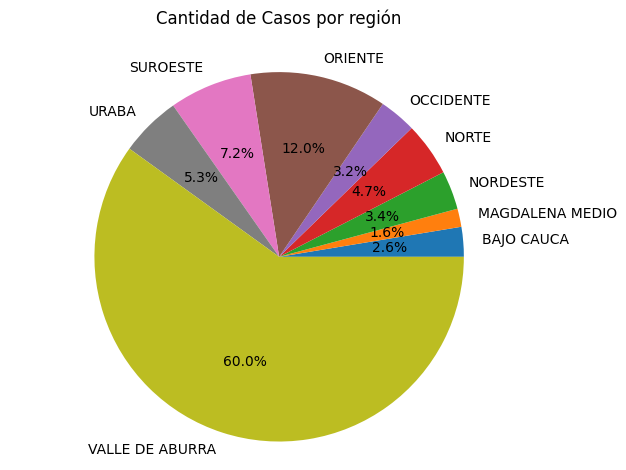

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

plt.pie(suma_casos_region['Casos'],
        labels=suma_casos_region['Region'],
        autopct="%0.1f%%") #Se crea una grafica de pastel

plt.axis("equal")
plt.title('Cantidad de Casos por región\n') #Titulo
plt.tight_layout()

plt.show()


In [21]:
#Agrupa los casos por aós para mostrar cuantos casos hubo en cada año
df_nuevo_nombre = df_nuevo_nombre[(df_nuevo_nombre['Anio'] >= 2005) & (df_nuevo_nombre['Anio'] <= 2024)]
suma_casos_anio = df_nuevo_nombre.groupby('Anio')['Casos'].sum().reset_index()

suma_casos_anio

,Anio,Casos
0,2005,327
1,2006,328
2,2007,296
3,2008,338
4,2009,335
5,2010,326
6,2011,325
7,2012,329
8,2013,330
9,2014,323


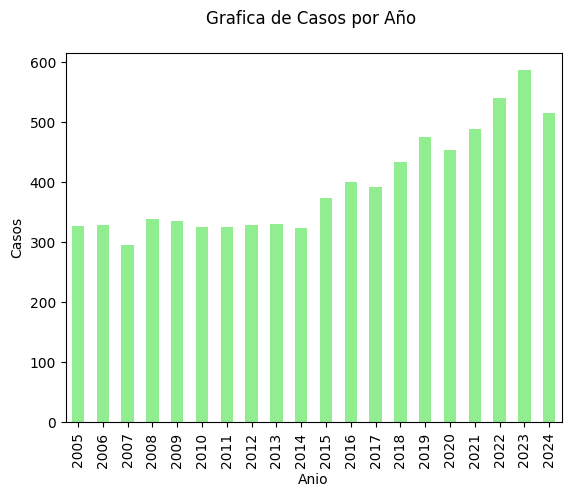

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Crear el gráfico directamente desde el DataFrame
suma_casos_anio.plot(kind='bar',
                     x='Anio',
                     y='Casos',
                     legend=False, color='lightgreen')

plt.title('Grafica de Casos por Año \n')
plt.ylabel('Casos')

plt.show()


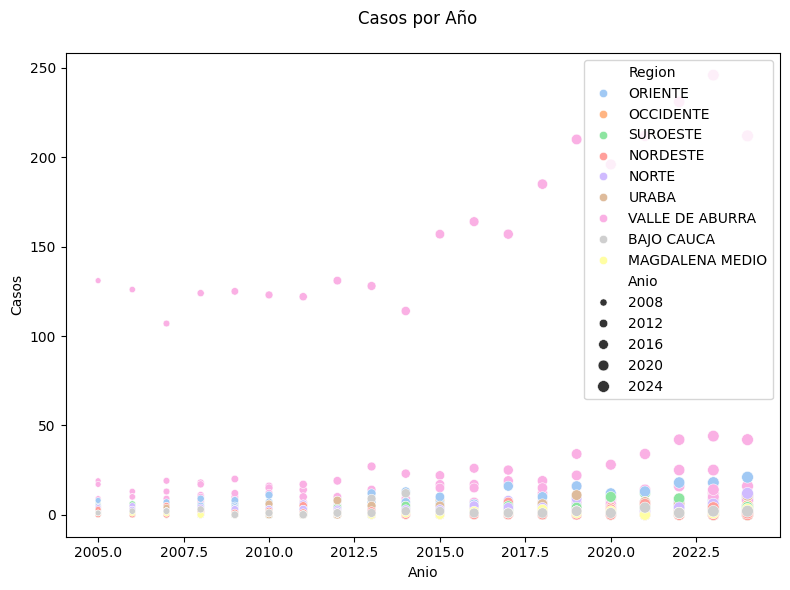

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Relación entre 'Año' y 'Casos', diferenciando por la región
df_nuevo_nombre = df_nuevo_nombre[(df_nuevo_nombre["Anio"] >= 2005) & (df_nuevo_nombre["Anio"] <= 2024)]
suma_casos_region = df_nuevo_nombre.groupby("Anio")["Casos"].sum().reset_index()

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_nuevo_nombre,
    x='Anio',
    y='Casos',
    hue='Region',
    size='Anio',
    palette='pastel'

)

plt.title('Casos por Año  \n')
plt.tight_layout()
#plt.savefig('diagrama.png', dpi=300, transparent=True)
plt.show()

In [24]:
#Excluir el valle de aburra:

excluir = [
    'VALLE DE ABURRA',
]
df_cont = df_nuevo_nombre[~df_nuevo_nombre['Region'].isin(excluir)]

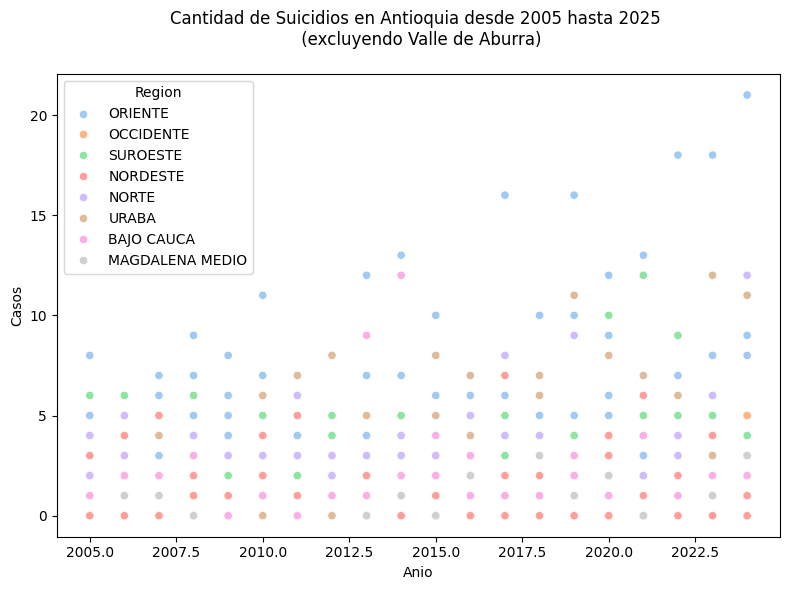

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_cont,
    x='Anio',
    y='Casos',
    hue='Region',
    #size='Anio',
    palette='pastel'

)

plt.title('Cantidad de Suicidios en Antioquia desde 2005 hasta 2025 \n (excluyendo Valle de Aburra)\n')
plt.tight_layout()
#plt.savefig('diagrama.png', dpi=300, transparent=True)
plt.show()

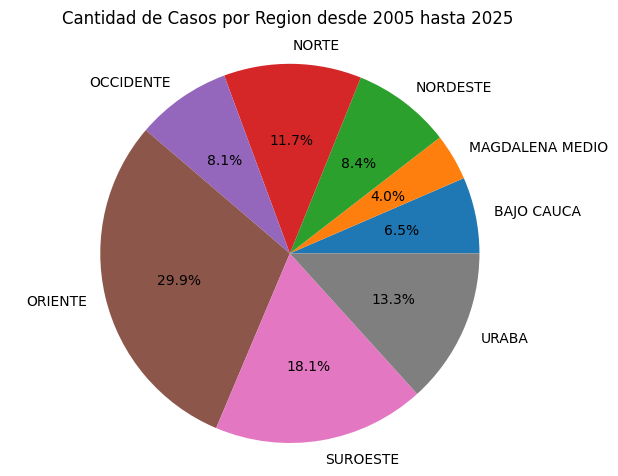

In [26]:
 #Agrupa los casos por region para mostrar cuantos casos hubo en cada region
df_cont = df_cont[(df_cont['Anio'] >= 2005) & (df_cont['Anio'] <= 2024)]
suma_casos_region = df_cont.groupby('Region')['Casos'].sum().reset_index()



umbral = 100
df_altos = suma_casos_region[suma_casos_region['Casos'] > umbral]

plt.pie(df_altos['Casos'], labels=df_altos['Region'],
        autopct="%0.1f%%") #Se crea una grafica de pastel

plt.axis("equal")
plt.title('Cantidad de Casos por Region desde 2005 hasta 2025 \n') #Titulo
plt.tight_layout()

plt.show()

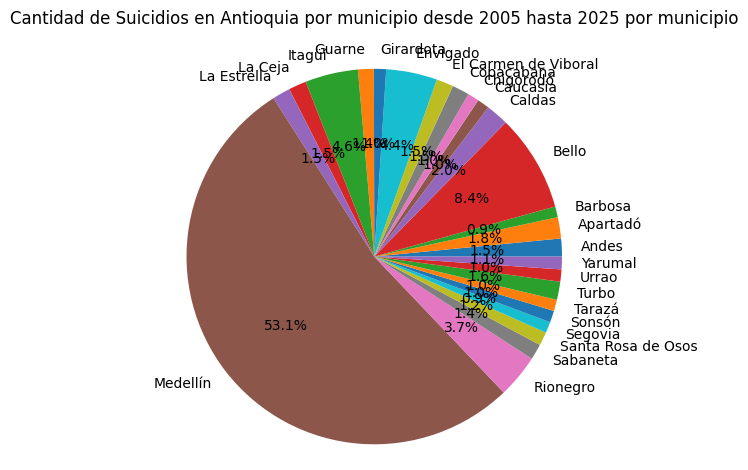

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

#Agrupa los casos por municipio para mostrar cuantos casos hubo en cada municipio en 20 años
df_nuevo_nombre = df_nuevo_nombre[(df_nuevo_nombre['Anio'] >= 2005) & (df_nuevo_nombre['Anio'] <= 2024)]
suma_casos_municipio = df_nuevo_nombre.groupby('Municipio')['Casos'].sum().reset_index()


umbral = 50 #Filtrar por un valor mínimo (ej. mayores a 50 suicidios por municipio)
df_altos = suma_casos_municipio[suma_casos_municipio['Casos'] > umbral]

plt.pie(df_altos['Casos'], labels=df_altos['Municipio'], autopct="%0.1f%%") #Se crea una grafica de pastel

plt.axis("equal")
plt.title('Cantidad de Suicidios en Antioquia por municipio desde 2005 hasta 2025 por municipio\n') #Titulo
plt.tight_layout()

plt.show()

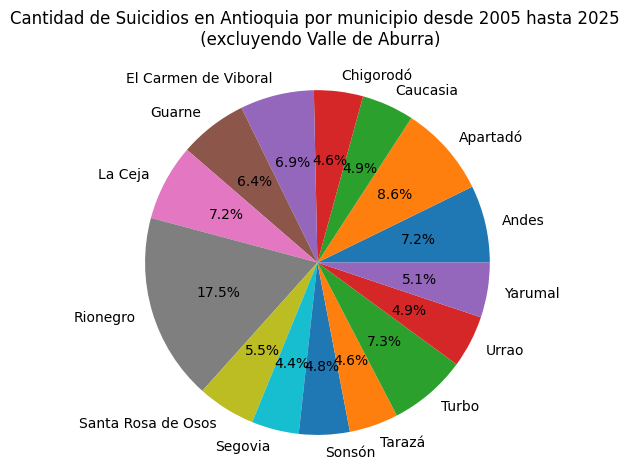

In [28]:
 #Agrupa los casos por region para mostrar cuantos casos hubo en cada region
df_cont = df_cont[(df_cont['Anio'] >= 2005) & (df_cont['Anio'] <= 2024)]
suma_casos_municipio = df_cont.groupby('Municipio')['Casos'].sum().reset_index()



umbral = 50 #Filtrar por un valor mínimo (ej. mayores a 50 suicidios por municipio)
df_altos = suma_casos_municipio[suma_casos_municipio['Casos'] > umbral]

plt.pie(df_altos['Casos'], labels=df_altos['Municipio'], autopct="%0.1f%%") #Se crea una grafica de pastel

plt.axis("equal")
plt.title('Cantidad de Suicidios en Antioquia por municipio desde 2005 hasta 2025 \n (excluyendo Valle de Aburra)\n') #Titulo
plt.tight_layout()

plt.show()

/tmp/ipython-input-802823757.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


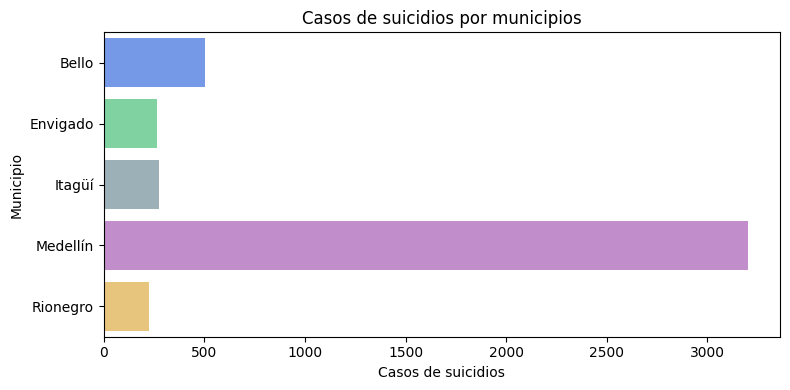

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

#Agrupa los casos por municipio para mostrar cuantos casos hubo en cada municipio en 20 años
df_nuevo_nombre = df_nuevo_nombre[(df_nuevo_nombre['Anio'] >= 2005) & (df_nuevo_nombre['Anio'] <= 2024)]
suma_casos_municipio = df_nuevo_nombre.groupby('Municipio')['Casos'].sum().reset_index()

umbral = 200 #Filtrar por un valor mínimo (ej. mayores a 50 suicidios por municipio)
df_altos = suma_casos_municipio[suma_casos_municipio['Casos'] > umbral]

plt.figure(figsize=(8,4))
sns.barplot(
    data=df_altos,
    x= 'Casos',
    y='Municipio',
    palette = 'blend:#6392FA,#78FA7E,#B66BFA,#FACB6B'
)

plt.title('Casos de suicidios por municipios')
plt.xlabel('Casos de suicidios')
plt.ylabel('Municipio')

plt.tight_layout()
plt.show()
# Darle amplit

In [30]:
 # Crear una Lista a partir de la variable departamento que se obtiene
    # del conteo de cada departamento de mayor a menor. Esto genera un
    # Dataframe, del cual traigo solo el índice -> Nombre del Departamento
    #order=df['Municipio'].value_counts().index,

In [31]:
import pandas as pd
import folium
from folium.plugins import HeatMap
import geopandas as gpd
import re


#Cargar límite de Antioquia
ant = gpd.read_file("https://github.com/evelynsaez/analisis_suicidios_antioquia/raw/refs/heads/data_zharita/antioquia.geojson").to_crs(epsg=4326)

#Crear mapa base
mapa = folium.Map(location=[6.55, -75.10], zoom_start=8, tiles="CartoDB positron")

#Dibujar borde del departamento
folium.GeoJson(
    ant,
    name="Antioquia",
    style_function=lambda x: {"fillOpacity": 0, "color": "black", "weight": 1}
).add_to(mapa)

# 6. Crear lista para el heatmap (lat, lon, casos)
heat_data = df_nuevo_nombre[["Lat", "Lon", "Casos"]].dropna().values.tolist()

# 7. Heatmap con PESO
HeatMap(
    heat_data,
    radius=20,     # tamaño del punto
    blur=15,       # difusión
    max_zoom=12,
    min_opacity=0.4
).add_to(mapa)

# 8. Guardar el mapa
mapa.save("mapa_calor_suicidios_pesado.html")

mapa


In [32]:
import pandas as pd
import folium
from folium.plugins import HeatMap
import geopandas as gpd
import re


# Agrupar total 20 años por municipio
totales = df_nuevo_nombre.groupby("Municipio")["Casos"].sum().reset_index().sort_values("Casos", ascending=False)

# Unir totales al dataframe original (para tomar coordenadas)
df_merged = df_nuevo_nombre.merge(totales, on="Municipio", suffixes=("", "_Total"))

# Tomar una sola fila por municipio (para el marcador)
df_muni = df_merged.drop_duplicates(subset=["Municipio"])

# Función de color por total de suicidios (20 años)
def color_total(casos):
    if casos <= 5:
        return "green"
    elif casos <= 20:
        return "orange"
    else:
        return "red"

# Cargar límite del departamento
ant = gpd.read_file("https://github.com/evelynsaez/analisis_suicidios_antioquia/raw/refs/heads/data_zharita/antioquia.geojson").to_crs(epsg=4326)

# Crear mapa base
mapa = folium.Map(location=[6.55, -75.10], zoom_start=8, tiles="CartoDB positron")

# Dibujar borde del departamento
folium.GeoJson(
    ant,
    name="Antioquia",
    style_function=lambda x: {"fillOpacity": 0, "color": "black", "weight": 1}
).add_to(mapa)

# Heatmap con casos individuales
heat_data = df_nuevo_nombre[["Lat", "Lon", "Casos"]].dropna().values.tolist()

HeatMap(
    heat_data,
    radius=20,
    blur=15,
    max_zoom=12,
    min_opacity=0.4
).add_to(mapa)

# Marcadores con total de suicidios por municipio
for _, row in df_muni.iterrows():
    total = row["Casos_Total"]
    color = color_total(total)

    popup_text = f"""
    <b>Municipio:</b> {row['Municipio']}<br>
    <b>Total suicidios en 20 años:</b> {int(total)}<br>

    """

    folium.CircleMarker(
        location=[row["Lat"], row["Lon"]],
        radius=8,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.9,
        popup=popup_text
    ).add_to(mapa)

# Guardar mapa final
mapa.save("mapa_suicidios_antioquia_mejorado.html")

mapa


In [33]:
import pandas as pd

#Calcular CASOS TOTALES por municipio en 20 años
totales_casos = df_nuevo_nombre.groupby("Municipio")["Casos"].sum()

#Calcular POBLACIÓN PROMEDIO por municipio en 20 años
promedio_poblacion = df_nuevo_nombre.groupby("Municipio")["Poblacion"].mean()

#Unir ambos resultados en un DataFrame
tasa_20 = pd.DataFrame({
    "Casos_20_anios": totales_casos,
    "Poblacion_promedio": promedio_poblacion
})

#Calcular la tasa acumulada por cada 100.000 habitantes
tasa_20["Tasa_20_anios"] = (tasa_20["Casos_20_anios"] / tasa_20["Poblacion_promedio"]) * 10000

#Ordenar de mayor a menor tasa
tasa_20 = tasa_20.sort_values(by="Tasa_20_anios", ascending=False)

tasa_20_nuevo_nombre = tasa_20.rename(columns={'Casos_20_anios': 'Casos', 'Poblacion_promedio': 'Poblacion promedio','Tasa_20_anios': 'Tasa'})

tasa_20

,Casos_20_anios,Poblacion_promedio,Tasa_20_anios
Municipio,,,
Valdivia,36,14050.60,25.621682
Tarazá,59,26156.05,22.556923
Andes,93,43135.55,21.559943
Campamento,20,9463.45,21.133942
El Peñol,42,20262.15,20.728304
...,...,...,...
Necoclí,17,41311.05,4.115122
Abriaquí,1,2701.30,3.701921
Vigía del Fuerte,2,8717.20,2.294315


/tmp/ipython-input-743299975.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


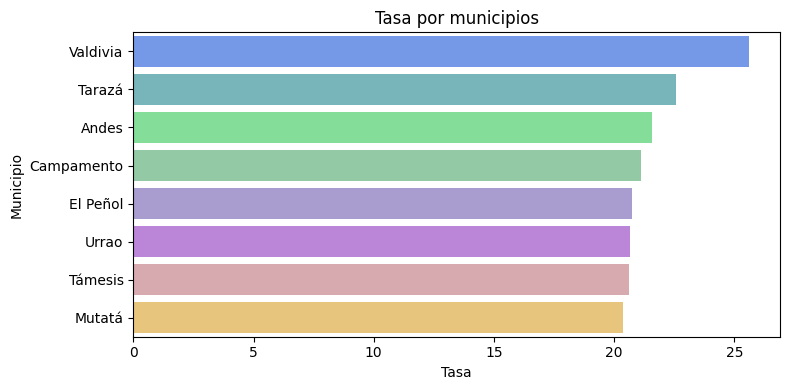

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

umbral = 20
df_altos_tasa = tasa_20_nuevo_nombre[tasa_20_nuevo_nombre['Tasa'] > umbral]

plt.figure(figsize=(8,4))
sns.barplot(
    data=df_altos_tasa,
    x= 'Tasa',
    y='Municipio',

    palette = 'blend:#6392FA,#78FA7E,#B66BFA,#FACB6B'
)

plt.title('Tasa por municipios')
plt.xlabel('Tasa')
plt.ylabel('Municipio')

plt.tight_layout()
plt.show()

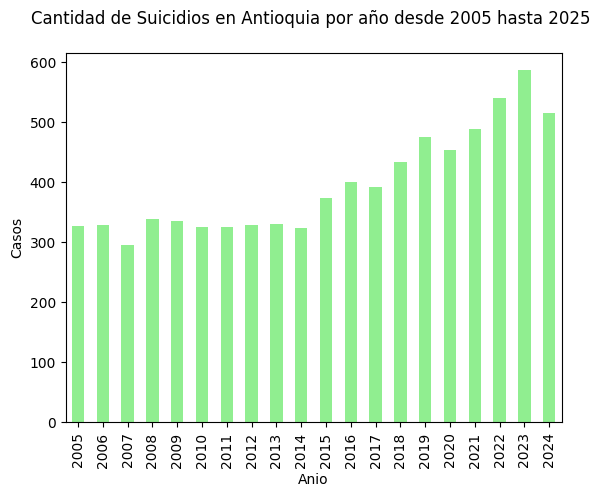

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# Crear el gráfico directamente desde el DataFrame
suma_casos_anio.plot(kind='bar', x='Anio', y='Casos', legend=False, color='lightgreen')

plt.title('Cantidad de Suicidios en Antioquia por año desde 2005 hasta 2025 \n')
plt.ylabel('Casos')

plt.show()

In [36]:
#¿Cómo sacar la tasa de suicidios del 2024 de los 10 municipios con más suicidios?
#informe ese sube a la plataforma juanto al codigo
#objetivos justificacion metodologia conclusiones
#diapositivas relevantes

In [37]:
municipios = ["Medellín", "Sabaneta", "Bello", 'Itagüí', 'La Estrella', 'Copacabana']

seleccion = tasa_20[tasa_20.index.isin(municipios)]
seleccion

,Casos_20_anios,Poblacion_promedio,Tasa_20_anios
Municipio,,,
La Estrella,93,66820.65,13.917853
Medellín,3201,2334869.15,13.709548
Copacabana,89,73767.85,12.064877
Sabaneta,82,74560.50,10.997780
Itagüí,275,262181.75,10.488907
Bello,504,486038.15,10.369556


/tmp/ipython-input-2816051720.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


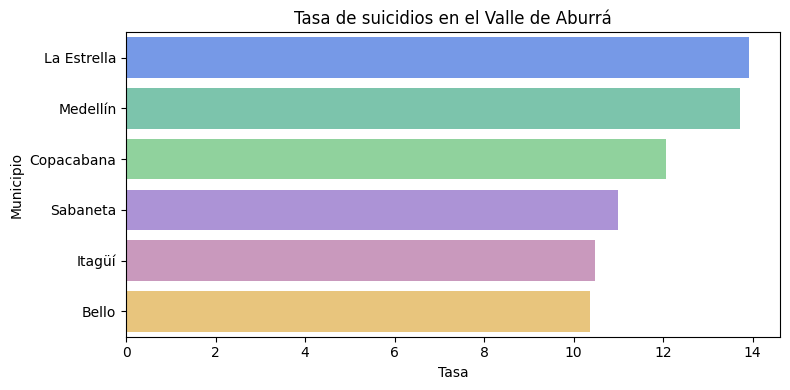

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.barplot(
    data=seleccion,
    x= 'Tasa_20_anios',
    y='Municipio',

    palette = 'blend:#6392FA,#78FA7E,#B66BFA,#FACB6B'
)

plt.title('Tasa de suicidios en el Valle de Aburrá')
plt.xlabel('Tasa')
plt.ylabel('Municipio')

plt.tight_layout()
plt.show()